In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from matplotlib.transforms import offset_copy
from matplotlib import colors
from mpl_toolkits.axes_grid1 import make_axes_locatable

from scipy.cluster.hierarchy import fcluster, linkage, dendrogram, cut_tree, leaves_list
from scipy.spatial.distance import pdist, squareform

In [2]:
%run LittRuP__import_functions.ipynb

In [3]:
# chemins vers fichiers Data et Images

BASE_DIR = Path.cwd()

if BASE_DIR.name == "Notebooks":
    BASE_DIR = BASE_DIR.parent

DAT_DIR = BASE_DIR / "Data"
IMG_DIR = BASE_DIR / "Images"
DOC_DIR = BASE_DIR / "Docs"

In [4]:
# import matrice étendue

matrix_all_extended = pd.read_csv(DAT_DIR / "LittRu_matrix_all_extended.csv", sep=',', header=0)

In [5]:
# indique que les thèmes sont toutes les colonnes situées après "CutOff"

theme_cols = matrix_all_extended.columns[
    matrix_all_extended.columns.get_loc("CutOff") + 1:
]

In [6]:
# matrice des thèmes 0/1

matrix_themes = matrix_all_extended[theme_cols]

In [7]:
# liste des oeuvres

the_works = matrix_all_extended["Works"].unique().tolist()

In [8]:
# liste des thèmes

the_themes = matrix_themes.columns.values.tolist()

**Distance de Jaccard entre oeuvres**

In [9]:
# la distance de Jaccard est calculée entre toutes les paires de lignes :
# 173 oeuvres => [173 x (173-1)]/2 paires (=14878)

MW = matrix_themes.to_numpy().astype(bool)

dist_jaccard_W = pdist(
    MW, 
    metric="jaccard"
)

**Clustering hiérarchique**

In [10]:
# linkage sur matrice de Jaccard

LW = linkage(
    dist_jaccard_W, 
    method="average"
)

**Dendrogramme des oeuvres**

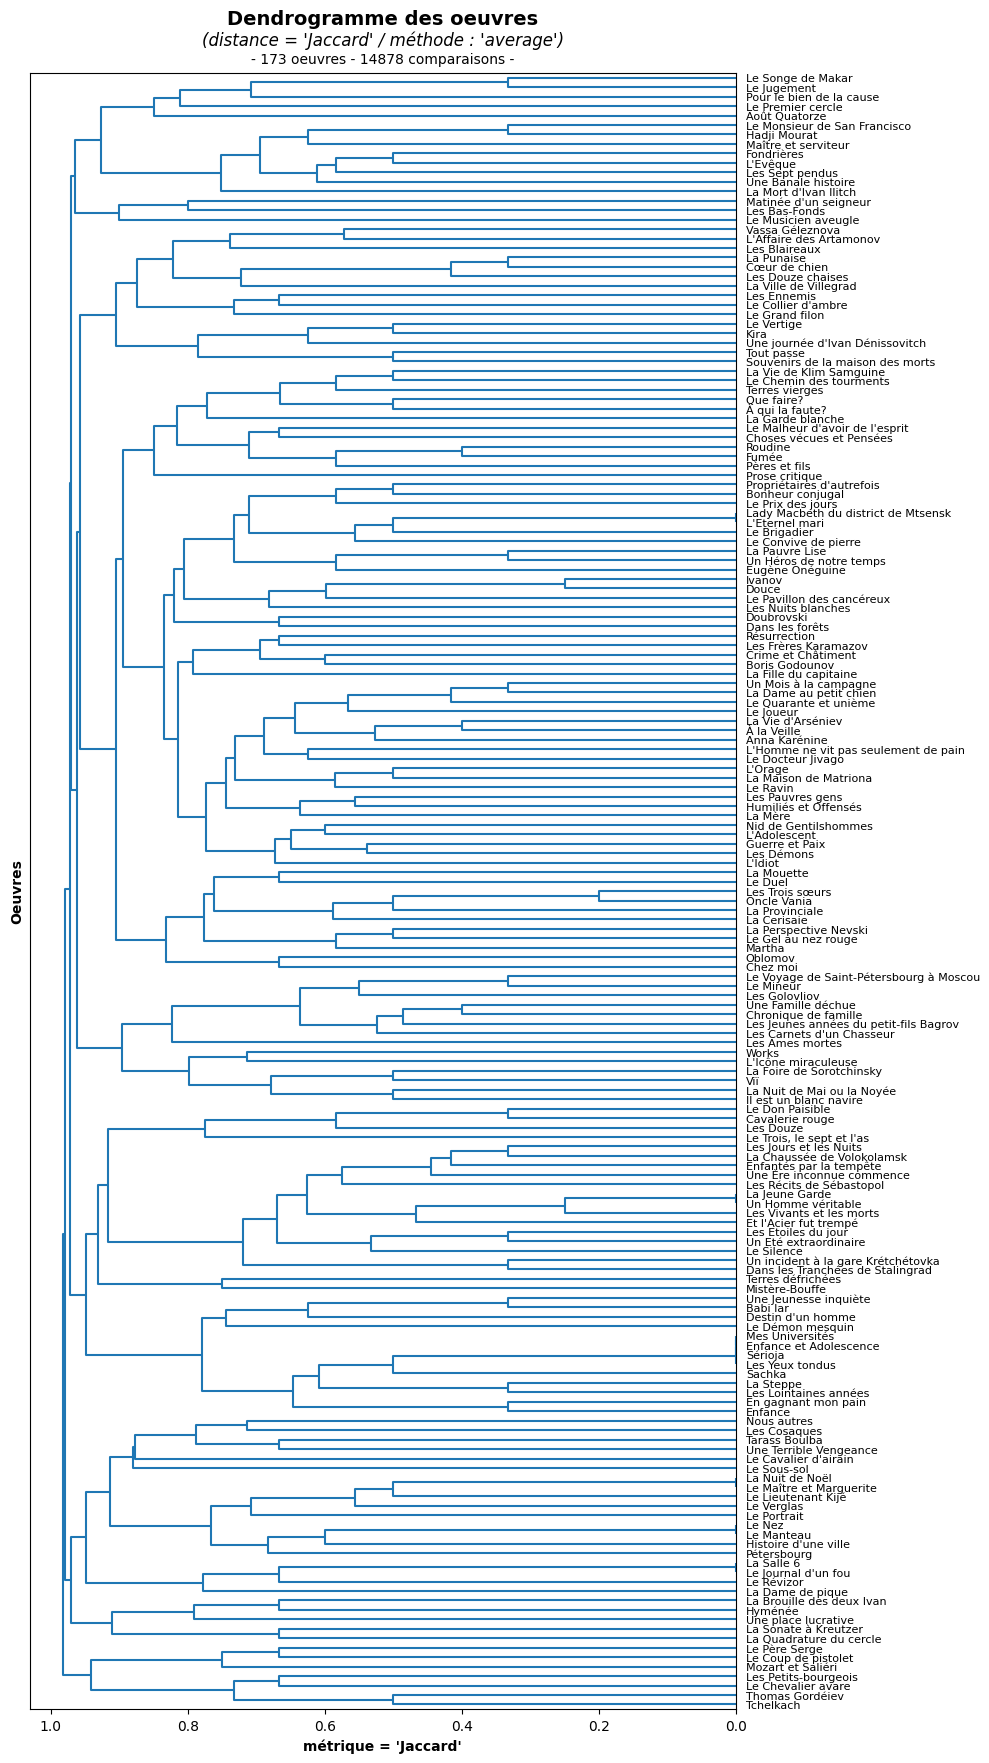

In [11]:

N_works = len(the_works)
N_dist_jaccard_W = len(dist_jaccard_W)

fig, ax = plt.subplots(figsize=(10, 18))

dendrogram(
    LW,
    labels=the_works,
    leaf_rotation=0, 
    leaf_font_size=8,
    orientation="left",
    color_threshold=0
)

ax.set_ylabel("Oeuvres", fontweight="bold")
ax.set_xlabel("métrique = 'Jaccard'", fontweight="bold")
ax.tick_params(axis="x", labelsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.95])

titres(
    fig,
    ax,
    t1="Dendrogramme des oeuvres", y1=35,
    t2="(distance = 'Jaccard' / méthode : 'average')", y2=20,
    t3=f"- {N_works} oeuvres - {N_dist_jaccard_W} comparaisons -", y3=7
)

fig.savefig(
    IMG_DIR / "oeuvres_dendrogramme.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

**Dendrogramme tronqué**

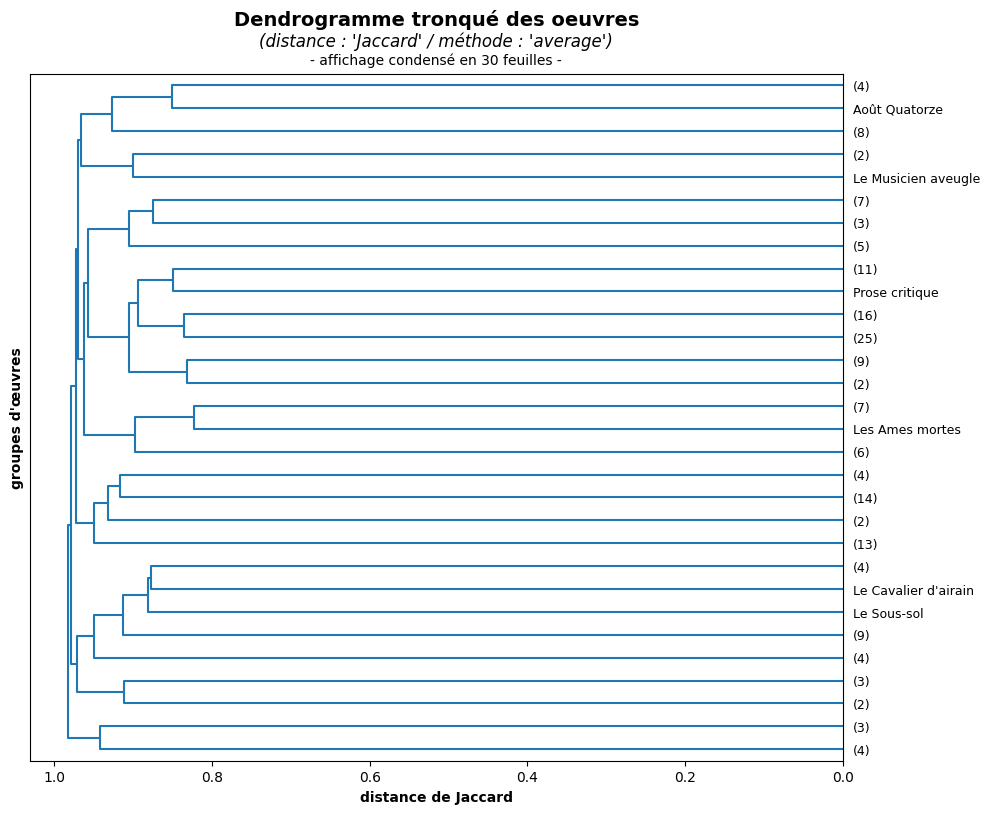

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))

dendrogram(
    LW,
    truncate_mode="lastp",
    p=30,
    labels=the_works,
    orientation="left",
    leaf_font_size=9,
    show_leaf_counts=True
)

ax.set_xlabel("distance de Jaccard", fontweight="bold")
ax.set_ylabel("groupes d'œuvres", fontweight="bold")

plt.tight_layout(rect=[0, 0, 1, 0.95])

titres(
    fig,
    ax,
    t1="Dendrogramme tronqué des oeuvres", y1=35,
    t2="(distance : 'Jaccard' / méthode : 'average')", y2=20,
    t3="- affichage condensé en 30 feuilles -", y3=7
)

fig.savefig(
    IMG_DIR / "oeuvres_dendrogramme_tronqué.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()
